## Xgboost 

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay,recall_score
from ax.service.managed_loop import optimize
import matplotlib.pyplot as plt
import time


In [2]:
path = r"C:\Users\tvlan\Documents\Data Mining\1.0 Assignment\2.0 Assignment 2\2.0 Dataset\early_sepsis_full_simulated_dataset_dropped_encoded_20260603_145114.csv"
df = pd.read_csv(path)
X = df.drop("sepsis_risk",axis =1)
y = df["sepsis_risk"]

In [73]:
y.value_counts()

sepsis_risk
0    765
1    235
Name: count, dtype: int64

In [59]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size = 0.3)

In [60]:
xgb_model = xgb.XGBClassifier()

In [61]:
xgb_model.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [62]:
y_pred = xgb_model.predict(X_test)

In [63]:
y_prob = xgb_model.predict_proba(X_test)[:,1]
a1= accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
sens = recall_score(y_test,y_pred)
print(f"accuray : {a1:.4}, f1_score: {f1:.4}, sensitivity : {sens:.4}")

accuray : 0.96, f1_score: 0.9178, sensitivity : 0.8701


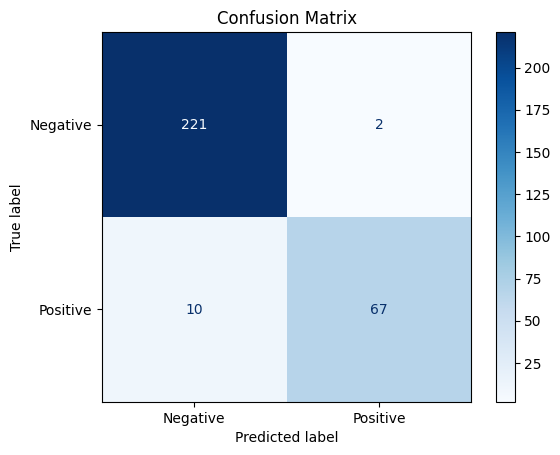

In [64]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels = ["Negative","Positive"],
    cmap=plt.cm.Blues
)

plt.title("Confusion Matrix")
plt.show()


In [58]:

def xgb_eval(parameterization):
    params = {
        'max_depth': parameterization.get('max_depth'),
        'learning_rate': parameterization.get('learning_rate'),
        'subsample': parameterization.get('subsample'),
        'colsample_bytree': parameterization.get('colsample_bytree'),
        'n_estimators': 100,
        'objective': 'binary:logistic',
        'random_state': 42,
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    y_proba = model.predict_proba(X_test)[:, 1]  # Fix 1: get probabilities
    auc = roc_auc_score(y_test, y_proba)          # Fix 1: compute real AUC
    return auc

parameters = [
    {"name": "max_depth", "type": "range", "bounds": [3, 10], "value_type": "int"},  # Fix 2
    {"name": "learning_rate", "type": "range", "bounds": [0.01, 0.3]},
    {"name": "subsample", "type": "range", "bounds": [0.5, 1.0]},
    {"name": "colsample_bytree", "type": "range", "bounds": [0.5, 1.0]},
]

best_parameters, best_values, experiment, model = optimize(
    parameters=parameters,
    evaluation_function=xgb_eval,
    objective_name='auc',
    total_trials=30,
    random_seed=42,
)

print(f"Best hyperparameters: {best_parameters}")
print(f"Best AUC: {best_values}")

[INFO 06-06 16:59:23] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.
[INFO 06-06 16:59:23] ax.api.client: Generated new trial 0 with parameters {'max_depth': 6, 'learning_rate': 0.155, 'subsample': 0.75, 'colsample_bytree': 0.75} using GenerationNode CenterOfSearchSpace.
[INFO 06-06 16:59:23] ax

Best hyperparameters: {'max_depth': 3, 'learning_rate': 0.21514634999212776, 'subsample': 0.943313084918944, 'colsample_bytree': 0.8098559003211636}
Best AUC: ({'auc': np.float64(0.9965970113129953)}, {'auc': {'auc': np.float64(4.471094612292166e-14)}})


In [57]:
# Retrain with best parameters
best_xgb = XGBClassifier(
    max_depth=best_parameters['max_depth'],
    learning_rate=best_parameters['learning_rate'],
    subsample=best_parameters['subsample'],
    colsample_bytree=best_parameters['colsample_bytree'],
    n_estimators=100,
    objective='binary:logistic',
    random_state=42,
)
best_xgb.fit(X_train, y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7508050038312151
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [42]:
# Get AUC-ROC
y_proba = best_xgb.predict_proba(X_test)[:, 1]
y_pred = best_xgb.predict(X_test)
auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test,y_pred)
sens = recall_score(y_test,y_pred)
print(f"AUC-ROC: {auc:.4f}\nF1: {f1:.4f}\nSensitivity: {sens:.4f}")

AUC-ROC: 0.9949
F1: 0.9020
Sensitivity: 0.8214


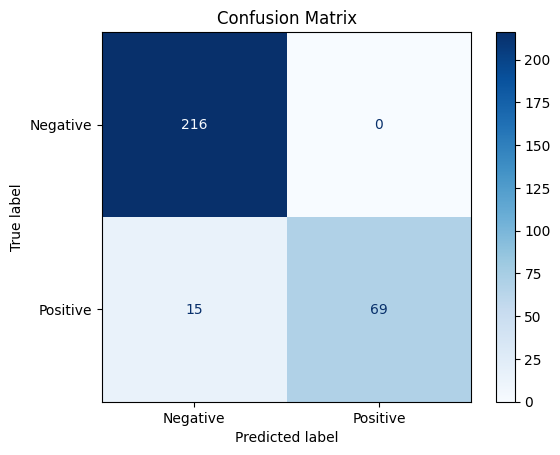

In [43]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels = ["Negative","Positive"],
    cmap=plt.cm.Blues
)

plt.title("Confusion Matrix")
plt.show()



In [ ]:
path = r"C:\Users\tvlan\Documents\Data Mining\1.0 Assignment\2.0 Assignment 2\2.0 Dataset\early_sepsis_full_simulated_dataset_dropped_encoded_20260603_145114.csv"


def confusionmat(y_test,y_pred,label0,label1):
    disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels = [label0,label1],
    cmap=plt.cm.Blues
)

    plt.title("Confusion Matrix")
    plt.show()

def datasetsetup(path,target,features =[]):

    df = pd.read_csv(path)

    if features == []:
        X = df.drop(target,axis =1)
    else:
        X = df.drop(target,axis =1)[features]

    y = df[target]

    X_train, X_test, y_train,y_test = train_test_split(X,y,test_size = 0.3)

    return X_train, X_test, y_train,y_test 


def xgboost(label0,label1,X_train, X_test, y_train,y_test):

    xgb_model = xgb.XGBClassifier()

    start = time()
    xgb_model.fit(X_train,y_train)
    y_pred = xgb_model.predict(X_test)
    y_prob = xgb_model.predict_proba(X_test)[:,1]
    end = time()
    
    a1= accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    sens = recall_score(y_test,y_pred)
    auc = roc_auc_score(y_test,y_prob)
    time_dur = (start-end)/60

    print(f"AUC-ROC: {auc:.4f}\nF1: {f1:.4f}\nSensitivity: {sens:.4f}\nTime: {time_dur:.4f}")
    confusionmat(y_test,y_pred,label0,label1)

    return "XGboost_norm",a1,f1,sens,auc

def xgboost_hp(xgb_eval,label0,label1,X_train, X_test, y_train,y_test):

    def xgb_eval(parameterization):
        params = {
            'max_depth': parameterization.get('max_depth'),
            'learning_rate': parameterization.get('learning_rate'),
            'subsample': parameterization.get('subsample'),
            'colsample_bytree': parameterization.get('colsample_bytree'),
            'n_estimators': 100,
            'objective': 'binary:logistic',
            'random_state': 42,
        }

        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        
        y_proba = model.predict_proba(X_test)[:, 1]  # Fix 1: get probabilities
        auc = roc_auc_score(y_test, y_proba)          # Fix 1: compute real AUC
        return auc
    
    parameters = [
        {"name": "max_depth", "type": "range", "bounds": [3, 10], "value_type": "int"},  # Fix 2
        {"name": "learning_rate", "type": "range", "bounds": [0.01, 0.3]},
        {"name": "subsample", "type": "range", "bounds": [0.5, 1.0]},
        {"name": "colsample_bytree", "type": "range", "bounds": [0.5, 1.0]},
    ]

    best_parameters, best_values, experiment, model = optimize(
        parameters=parameters,
        evaluation_function=xgb_eval,
        objective_name='auc',
        total_trials=30,
        random_seed=42,
    )

    best_xgb = XGBClassifier(
    max_depth=best_parameters['max_depth'],
    learning_rate=best_parameters['learning_rate'],
    subsample=best_parameters['subsample'],
    colsample_bytree=best_parameters['colsample_bytree'],
    n_estimators=100,
    objective='binary:logistic',
    random_state=42,
    )
    
    best_xgb.fit(X_train, y_train)

    start = time()

    y_proba = best_xgb.predict_proba(X_test)[:, 1]
    y_pred = best_xgb.predict(X_test)

    end = time()

    a1= accuracy_score(y_test,y_pred)
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test,y_pred)
    sens = recall_score(y_test,y_pred)
    time_dur = (start-end)/60

    print(f"AUC-ROC: {auc:.4f}\nF1: {f1:.4f}\nSensitivity: {sens:.4f}\nTime: {time_dur:.4f}")
    confusionmat(y_test,y_pred,label0,label1)

    return "XGboost_hp",a1,f1,sens,auc

def run(path,target,label0,label1,features =[]):
    X_train, X_test, y_train,y_test = datasetsetup(path,target,features =[])
    XG = xgboost(label0,label1,X_train, X_test, y_train,y_test)
    XG_hp = xgboost_hp(xgb_eval,label0,label1,X_train, X_test, y_train,y_test)




    

{
    "XGboost" : {
        "before" : {
            "roc_auc" : ,
            "sensitivity" : ,
            "accuracy" : ,
            "f1_score": ,


        },
        after :{
            
        }
    },

    "Decision Tree" : {

    }


}

XGBoost Basic Results:
AUC-ROC: 0.9961
F1: 0.9333
Sensitivity: 0.8889
Accuracy: 0.9733
Time: 0.0009 minutes


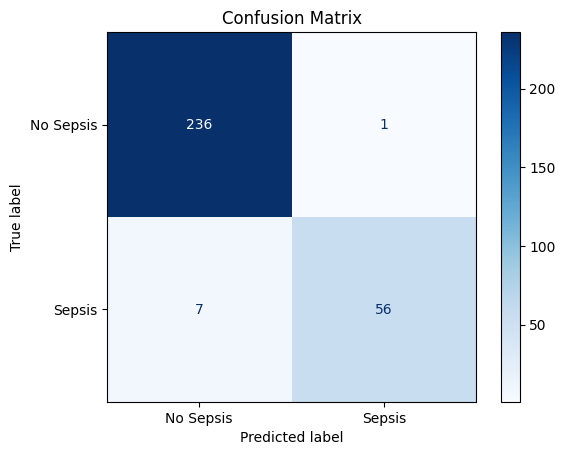

100%|██████████| 30/30 [00:02<00:00, 13.06trial/s, best loss: -0.9972540352287187]

XGBoost Hyperparameter Tuned Results:
Best Parameters: {'colsample_bytree': np.float64(0.6971545396242032), 'learning_rate': np.float64(0.2779510422213634), 'max_depth': np.float64(9.0), 'subsample': np.float64(0.9760502627889557)}
AUC-ROC: 0.9973
F1: 0.9412
Sensitivity: 0.8889
Accuracy: 0.9767
Time: 0.0014 minutes


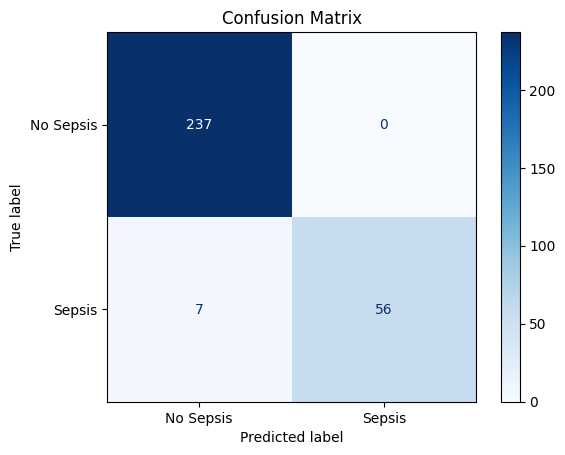


Decision Tree Results:
AUC-ROC: 0.7694
F1: 0.6446
Sensitivity: 0.6190
Accuracy: 0.8567
Time: 0.0001 minutes


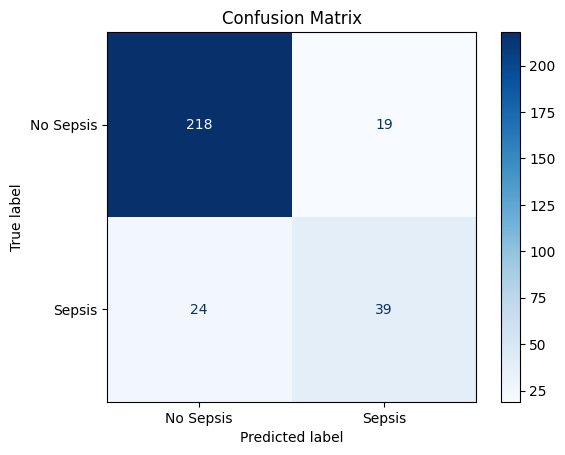


Decision Tree Hyperparameter Tuned Results:
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
AUC-ROC: 0.8736
F1: 0.5143
Sensitivity: 0.4286
Accuracy: 0.8300
Time: 0.2290 minutes


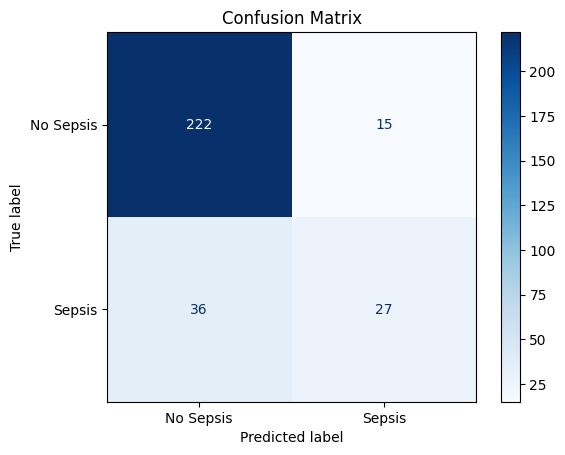

{
    "XGboost": {
        "before": {
            "roc_auc": 0.9961,
            "sensitivity": 0.8889,
            "accuracy": 0.9733,
            "f1_score": 0.9333,
            "time_minutes": 0.0009
        },
        "after": {
            "roc_auc": 0.9973,
            "sensitivity": 0.8889,
            "accuracy": 0.9767,
            "f1_score": 0.9412,
            "time_minutes": 0.0014,
            "best_params": {
                "colsample_bytree": 0.6971545396242032,
                "learning_rate": 0.2779510422213634,
                "max_depth": 9.0,
                "subsample": 0.9760502627889557
            }
        }
    },
    "Decision Tree": {
        "before": {
            "roc_auc": 0.7694,
            "sensitivity": 0.619,
            "accuracy": 0.8567,
            "f1_score": 0.6446,
            "time_minutes": 0.0001
        },
        "after": {
            "roc_auc": 0.8736,
            "sensitivity": 0.4286,
            "accuracy": 0.83,
            "f1_

In [65]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, ConfusionMatrixDisplay
import xgboost as xgb
from xgboost import XGBClassifier
from time import time
import matplotlib.pyplot as plt
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
import warnings
warnings.filterwarnings('ignore')

class ModelEvaluator:
    def __init__(self, path, target, label0, label1, features=[]):
        """
        Initialize the evaluator with dataset path and parameters
        
        Parameters:
        - path: path to the CSV file
        - target: name of target column
        - label0: label for negative class
        - label1: label for positive class
        - features: list of features to use (empty for all features)
        """
        self.path = path
        self.target = target
        self.label0 = label0
        self.label1 = label1
        self.features = features
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.results = {
            "XGboost": {
                "before": {},
                "after": {}
            },
            "Decision Tree": {}
        }
    
    def confusionmat(self, y_test, y_pred, label0, label1):
        """Plot confusion matrix"""
        disp = ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            display_labels=[label0, label1],
            cmap=plt.cm.Blues
        )
        plt.title("Confusion Matrix")
        plt.show()
    
    def datasetsetup(self):
        """Setup train-test split"""
        df = pd.read_csv(self.path)
        
        if self.features == []:
            X = df.drop(self.target, axis=1)
        else:
            X = df[self.features]
        
        y = df[self.target]
        
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )
        
        return self.X_train, self.X_test, self.y_train, self.y_test
    
    def xgboost(self):
        """Run basic XGBoost model"""
        xgb_model = xgb.XGBClassifier(random_state=42)
        
        start = time()
        xgb_model.fit(self.X_train, self.y_train)
        y_pred = xgb_model.predict(self.X_test)
        y_prob = xgb_model.predict_proba(self.X_test)[:, 1]
        end = time()
        
        accuracy = accuracy_score(self.y_test, y_pred)
        f1 = f1_score(self.y_test, y_pred)
        sensitivity = recall_score(self.y_test, y_pred)
        auc = roc_auc_score(self.y_test, y_prob)
        time_dur = (end - start) / 60
        
        print(f"XGBoost Basic Results:")
        print(f"AUC-ROC: {auc:.4f}\nF1: {f1:.4f}\nSensitivity: {sensitivity:.4f}\nAccuracy: {accuracy:.4f}\nTime: {time_dur:.4f} minutes")
        self.confusionmat(self.y_test, y_pred, self.label0, self.label1)
        
        return {
            "roc_auc": round(auc, 4),
            "sensitivity": round(sensitivity, 4),
            "accuracy": round(accuracy, 4),
            "f1_score": round(f1, 4),
            "time_minutes": round(time_dur, 4)
        }
    
    def xgboost_hp(self):
        """Run XGBoost with hyperparameter optimization"""
        
        def objective(params):
            """Objective function for hyperparameter optimization"""
            model = XGBClassifier(
                max_depth=int(params['max_depth']),
                learning_rate=params['learning_rate'],
                subsample=params['subsample'],
                colsample_bytree=params['colsample_bytree'],
                n_estimators=100,
                objective='binary:logistic',
                random_state=42,
                eval_metric='logloss'
            )
            model.fit(self.X_train, self.y_train)
            y_proba = model.predict_proba(self.X_test)[:, 1]
            auc = roc_auc_score(self.y_test, y_proba)
            return {'loss': -auc, 'status': STATUS_OK}
        
        # Define search space
        space = {
            'max_depth': hp.quniform('max_depth', 3, 10, 1),
            'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
            'subsample': hp.uniform('subsample', 0.5, 1.0),
            'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
        }
        
        # Run optimization
        trials = Trials()
        best = fmin(
            fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=30,
            trials=trials,
            rstate=np.random.default_rng(42)
        )
        
        # Train best model
        best_xgb = XGBClassifier(
            max_depth=int(best['max_depth']),
            learning_rate=best['learning_rate'],
            subsample=best['subsample'],
            colsample_bytree=best['colsample_bytree'],
            n_estimators=100,
            objective='binary:logistic',
            random_state=42,
        )
        
        start = time()
        best_xgb.fit(self.X_train, self.y_train)
        y_proba = best_xgb.predict_proba(self.X_test)[:, 1]
        y_pred = best_xgb.predict(self.X_test)
        end = time()
        
        accuracy = accuracy_score(self.y_test, y_pred)
        auc = roc_auc_score(self.y_test, y_proba)
        f1 = f1_score(self.y_test, y_pred)
        sensitivity = recall_score(self.y_test, y_pred)
        time_dur = (end - start) / 60
        
        print(f"\nXGBoost Hyperparameter Tuned Results:")
        print(f"Best Parameters: {best}")
        print(f"AUC-ROC: {auc:.4f}\nF1: {f1:.4f}\nSensitivity: {sensitivity:.4f}\nAccuracy: {accuracy:.4f}\nTime: {time_dur:.4f} minutes")
        self.confusionmat(self.y_test, y_pred, self.label0, self.label1)
        
        return {
            "roc_auc": round(auc, 4),
            "sensitivity": round(sensitivity, 4),
            "accuracy": round(accuracy, 4),
            "f1_score": round(f1, 4),
            "time_minutes": round(time_dur, 4),
            "best_params": best
        }
    
    def decision_tree(self):
        """Run Decision Tree model"""
        from sklearn.tree import DecisionTreeClassifier
        
        dt_model = DecisionTreeClassifier(random_state=42)
        
        start = time()
        dt_model.fit(self.X_train, self.y_train)
        y_pred = dt_model.predict(self.X_test)
        y_prob = dt_model.predict_proba(self.X_test)[:, 1]
        end = time()
        
        accuracy = accuracy_score(self.y_test, y_pred)
        f1 = f1_score(self.y_test, y_pred)
        sensitivity = recall_score(self.y_test, y_pred)
        auc = roc_auc_score(self.y_test, y_prob)
        time_dur = (end - start) / 60
        
        print(f"\nDecision Tree Results:")
        print(f"AUC-ROC: {auc:.4f}\nF1: {f1:.4f}\nSensitivity: {sensitivity:.4f}\nAccuracy: {accuracy:.4f}\nTime: {time_dur:.4f} minutes")
        self.confusionmat(self.y_test, y_pred, self.label0, self.label1)
        
        return {
            "roc_auc": round(auc, 4),
            "sensitivity": round(sensitivity, 4),
            "accuracy": round(accuracy, 4),
            "f1_score": round(f1, 4),
            "time_minutes": round(time_dur, 4)
        }
    
    def decision_tree_hp(self):
        """Run Decision Tree with hyperparameter optimization"""
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.model_selection import GridSearchCV
        
        # Define parameter grid
        param_grid = {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy']
        }
        
        dt_model = DecisionTreeClassifier(random_state=42)
        
        start = time()
        grid_search = GridSearchCV(
            dt_model, 
            param_grid, 
            cv=5, 
            scoring='roc_auc',
            n_jobs=-1
        )
        grid_search.fit(self.X_train, self.y_train)
        
        best_dt = grid_search.best_estimator_
        y_pred = best_dt.predict(self.X_test)
        y_prob = best_dt.predict_proba(self.X_test)[:, 1]
        end = time()
        
        accuracy = accuracy_score(self.y_test, y_pred)
        auc = roc_auc_score(self.y_test, y_prob)
        f1 = f1_score(self.y_test, y_pred)
        sensitivity = recall_score(self.y_test, y_pred)
        time_dur = (end - start) / 60
        
        print(f"\nDecision Tree Hyperparameter Tuned Results:")
        print(f"Best Parameters: {grid_search.best_params_}")
        print(f"AUC-ROC: {auc:.4f}\nF1: {f1:.4f}\nSensitivity: {sensitivity:.4f}\nAccuracy: {accuracy:.4f}\nTime: {time_dur:.4f} minutes")
        self.confusionmat(self.y_test, y_pred, self.label0, self.label1)
        
        return {
            "roc_auc": round(auc, 4),
            "sensitivity": round(sensitivity, 4),
            "accuracy": round(accuracy, 4),
            "f1_score": round(f1, 4),
            "time_minutes": round(time_dur, 4),
            "best_params": grid_search.best_params_
        }
    
    def run(self, include_decision_tree=True):
        """
        Run all models and return results in the specified format
        
        Parameters:
        - include_decision_tree: whether to include Decision Tree models
        """
        # Setup dataset
        self.datasetsetup()
        
        # Run XGBoost models
        self.results["XGboost"]["before"] = self.xgboost()
        self.results["XGboost"]["after"] = self.xgboost_hp()
        
        # Run Decision Tree models if requested
        if include_decision_tree:
            self.results["Decision Tree"]["before"] = self.decision_tree()
            self.results["Decision Tree"]["after"] = self.decision_tree_hp()
        
        return self.results


# Usage example:
if __name__ == "__main__":
    path = r"C:\Users\tvlan\Documents\Data Mining\1.0 Assignment\2.0 Assignment 2\2.0 Dataset\early_sepsis_full_simulated_dataset_dropped_encoded_20260603_145114.csv"
    
    # Create evaluator instance
    evaluator = ModelEvaluator(
        path=path,
        target="sepsis_risk",  # Replace with actual target column name
        label0="No Sepsis",
        label1="Sepsis",
        features=[]  # Empty list means use all features
    )
    
    # Run all models and get results
    results = evaluator.run(include_decision_tree=True)
    
    # Print formatted results
    import json
    print(json.dumps(results, indent=4))

AUC-ROC: 0.9961
F1: 0.9333
Sensitivity: 0.8889
Time: 0.0010


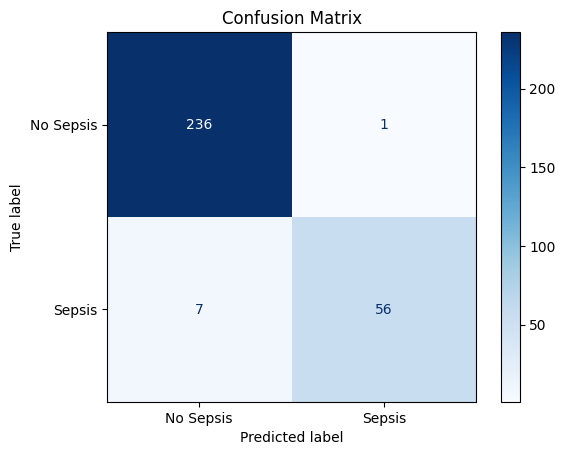

[INFO 06-06 17:16:07] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.
[INFO 06-06 17:16:07] ax.api.client: Generated new trial 0 with parameters {'max_depth': 6, 'learning_rate': 0.155, 'subsample': 0.75, 'colsample_bytree': 0.75} using GenerationNode CenterOfSearchSpace.
[INFO 06-06 17:16:07] ax

AUC-ROC: 0.9987
F1: 0.9587
Sensitivity: 0.9206
Time: 0.0002


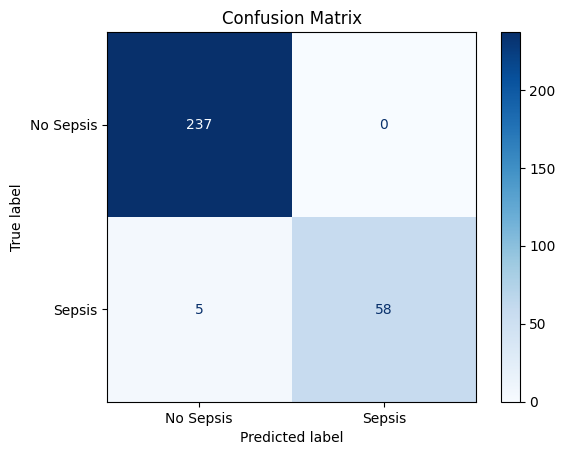

{'XGBoost': {'before': {'roc_auc': 0.9961154644698949, 'sensitivity': 0.8888888888888888, 'accuracy': 0.9733333333333334, 'f1_score': 0.9333333333333333}, 'after': {'roc_auc': 0.998727479740138, 'sensitivity': 0.9206349206349206, 'accuracy': 0.9833333333333333, 'f1_score': 0.9586776859504132}}}


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    roc_auc_score, ConfusionMatrixDisplay
)
from ax.service.managed_loop import optimize
from time import time


class SepsisClassifier:

    def __init__(self, path, target, label0, label1, features=[]):
        self.path = path
        self.target = target
        self.label0 = label0
        self.label1 = label1
        self.features = features
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

    def confusionmat(self, y_test, y_pred, label0, label1):
        disp = ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            display_labels=[label0, label1],
            cmap=plt.cm.Blues
        )
        plt.title("Confusion Matrix")
        plt.show()

    def datasetsetup(self, path, target, features=[]):
        df = pd.read_csv(path)

        if features == []:
            X = df.drop(target, axis=1)
        else:
            X = df.drop(target, axis=1)[features]

        y = df[target]

        # Fix 4: added random_state for reproducibility
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)

        return X_train, X_test, y_train, y_test

    def xgboost(self, label0, label1, X_train, X_test, y_train, y_test):
        xgb_model = xgb.XGBClassifier(random_state=42)

        start = time()
        xgb_model.fit(X_train, y_train)
        y_pred = xgb_model.predict(X_test)
        y_prob = xgb_model.predict_proba(X_test)[:, 1]
        end = time()

        a1 = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        sens = recall_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        time_dur = (end - start) / 60  # Fix 1: was (start - end)

        print(f"AUC-ROC: {auc:.4f}\nF1: {f1:.4f}\nSensitivity: {sens:.4f}\nTime: {time_dur:.4f}")
        self.confusionmat(y_test, y_pred, label0, label1)

        return "XGboost_norm", a1, f1, sens, auc

    def xgboost_hp(self, label0, label1, X_train, X_test, y_train, y_test):  # Fix 2: removed dead xgb_eval param

        def xgb_eval(parameterization):
            params = {
                'max_depth': parameterization.get('max_depth'),
                'learning_rate': parameterization.get('learning_rate'),
                'subsample': parameterization.get('subsample'),
                'colsample_bytree': parameterization.get('colsample_bytree'),
                'n_estimators': 100,
                'objective': 'binary:logistic',
                'random_state': 42,
            }

            model = XGBClassifier(**params)
            model.fit(X_train, y_train)

            y_proba = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_proba)
            return auc

        parameters = [
            {"name": "max_depth", "type": "range", "bounds": [3, 10], "value_type": "int"},
            {"name": "learning_rate", "type": "range", "bounds": [0.01, 0.3]},
            {"name": "subsample", "type": "range", "bounds": [0.5, 1.0]},
            {"name": "colsample_bytree", "type": "range", "bounds": [0.5, 1.0]},
        ]

        best_parameters, best_values, experiment, model = optimize(
            parameters=parameters,
            evaluation_function=xgb_eval,
            objective_name='auc',
            total_trials=30,
            random_seed=42,
        )

        best_xgb = XGBClassifier(
            max_depth=best_parameters['max_depth'],
            learning_rate=best_parameters['learning_rate'],
            subsample=best_parameters['subsample'],
            colsample_bytree=best_parameters['colsample_bytree'],
            n_estimators=100,
            objective='binary:logistic',
            random_state=42,
        )

        best_xgb.fit(X_train, y_train)

        start = time()
        y_proba = best_xgb.predict_proba(X_test)[:, 1]
        y_pred = best_xgb.predict(X_test)
        end = time()

        a1 = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        f1 = f1_score(y_test, y_pred)
        sens = recall_score(y_test, y_pred)
        time_dur = (end - start) / 60  # Fix 1: was (start - end)

        print(f"AUC-ROC: {auc:.4f}\nF1: {f1:.4f}\nSensitivity: {sens:.4f}\nTime: {time_dur:.4f}")
        self.confusionmat(y_test, y_pred, label0, label1)

        return "XGboost_hp", a1, f1, sens, auc

    def run(self):
        self.X_train, self.X_test, self.y_train, self.y_test = self.datasetsetup(
            self.path, self.target, features=self.features  # Fix 3: was hardcoded features=[]
        )

        _, a1_xg, f1_xg, sens_xg, auc_xg = self.xgboost(
            self.label0, self.label1,
            self.X_train, self.X_test, self.y_train, self.y_test
        )

        _, a1_xg_hp, f1_xg_hp, sens_xg_hp, auc_xg_hp = self.xgboost_hp(  # Fix 5: removed None arg
            self.label0, self.label1,
            self.X_train, self.X_test, self.y_train, self.y_test
        )

        results = {
            "XGBoost": {
                "before": {
                    "roc_auc": auc_xg,
                    "sensitivity": sens_xg,
                    "accuracy": a1_xg,
                    "f1_score": f1_xg,
                },
                "after": {
                    "roc_auc": auc_xg_hp,
                    "sensitivity": sens_xg_hp,
                    "accuracy": a1_xg_hp,
                    "f1_score": f1_xg_hp,
                }
            }
        }

        return results


# Usage
path = r"C:\Users\tvlan\Documents\Data Mining\1.0 Assignment\2.0 Assignment 2\2.0 Dataset\early_sepsis_full_simulated_dataset_dropped_encoded_20260603_145114.csv"

clf = SepsisClassifier(
    path=path,
    target="sepsis_risk",   # replace with your actual target column name
    label0="No Sepsis",
    label1="Sepsis"
)

results = clf.run()
print(results)

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    roc_auc_score, ConfusionMatrixDisplay
)
from ax.service.managed_loop import optimize
from time import time


class SepsisClassifier:

    def __init__(self, path, target, label0, label1, iter, features=[]):
        self.path = path
        self.target = target
        self.label0 = label0
        self.label1 = label1
        self.features = features
        self.iter = iter
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

    def confusionmat(self, y_test, y_pred, label0, label1):
        disp = ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            display_labels=[label0, label1],
            cmap=plt.cm.Blues
        )
        plt.title("Confusion Matrix")
        plt.show()

    def datasetsetup(self, path, target, features=[]):
        df = pd.read_csv(path)

        if features == []:
            X = df.drop(target, axis=1)
        else:
            X = df.drop(target, axis=1)[features]

        y = df[target]

        # Fix 4: added random_state for reproducibility
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)

        return X_train, X_test, y_train, y_test

    def xgboost(self, label0, label1, X_train, X_test, y_train, y_test):
        xgb_model = xgb.XGBClassifier(random_state=42)

        start = time()
        xgb_model.fit(X_train, y_train)
        y_pred = xgb_model.predict(X_test)
        y_prob = xgb_model.predict_proba(X_test)[:, 1]
        end = time()

        a1 = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        sens = recall_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        time_dur = (end - start) / 60  # Fix 1: was (start - end)

        print(f"AUC-ROC: {auc:.4f}\nF1: {f1:.4f}\nSensitivity: {sens:.4f}\nTime: {time_dur:.4f}")
        self.confusionmat(y_test, y_pred, label0, label1)

        return "XGboost_norm", a1, f1, sens, auc

    def xgboost_hp(self, label0, label1, X_train, X_test, y_train, y_test):  # Fix 2: removed dead xgb_eval param

        def xgb_eval(parameterization):
            params = {
                'max_depth': parameterization.get('max_depth'),
                'learning_rate': parameterization.get('learning_rate'),
                'subsample': parameterization.get('subsample'),
                'colsample_bytree': parameterization.get('colsample_bytree'),
                'n_estimators': 100,
                'objective': 'binary:logistic',
                'random_state': 42,
            }

            model = XGBClassifier(**params)
            model.fit(X_train, y_train)

            y_proba = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_proba)
            return auc

        parameters = [
            {"name": "max_depth", "type": "range", "bounds": [3, 10], "value_type": "int"},
            {"name": "learning_rate", "type": "range", "bounds": [0.01, 0.3]},
            {"name": "subsample", "type": "range", "bounds": [0.5, 1.0]},
            {"name": "colsample_bytree", "type": "range", "bounds": [0.5, 1.0]},
        ]

        best_parameters, best_values, experiment, model = optimize(
            parameters=parameters,
            evaluation_function=xgb_eval,
            objective_name='auc',
            total_trials=self.iter,
            random_seed=42,
        )

        best_xgb = XGBClassifier(
            max_depth=best_parameters['max_depth'],
            learning_rate=best_parameters['learning_rate'],
            subsample=best_parameters['subsample'],
            colsample_bytree=best_parameters['colsample_bytree'],
            n_estimators=100,
            objective='binary:logistic',
            random_state=42,
        )

        best_xgb.fit(X_train, y_train)

        start = time()
        y_proba = best_xgb.predict_proba(X_test)[:, 1]
        y_pred = best_xgb.predict(X_test)
        end = time()

        a1 = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        f1 = f1_score(y_test, y_pred)
        sens = recall_score(y_test, y_pred)
        time_dur = (end - start) / 60  # Fix 1: was (start - end)

        print(f"AUC-ROC: {auc:.4f}\nF1: {f1:.4f}\nSensitivity: {sens:.4f}\nTime: {time_dur:.4f}")
        self.confusionmat(y_test, y_pred, label0, label1)

        return "XGboost_hp", a1, f1, sens, auc

    def run(self):
        self.X_train, self.X_test, self.y_train, self.y_test = self.datasetsetup(
            self.path, self.target, features=self.features  # Fix 3: was hardcoded features=[]
        )

        _, a1_xg, f1_xg, sens_xg, auc_xg = self.xgboost(
            self.label0, self.label1,
            self.X_train, self.X_test, self.y_train, self.y_test
        )

        _, a1_xg_hp, f1_xg_hp, sens_xg_hp, auc_xg_hp = self.xgboost_hp(  # Fix 5: removed None arg
            self.label0, self.label1,
            self.X_train, self.X_test, self.y_train, self.y_test
        )

        results = {
            "XGBoost": {
                "before": {
                    "roc_auc": auc_xg,
                    "sensitivity": sens_xg,
                    "accuracy": a1_xg,
                    "f1_score": f1_xg,
                },
                "after": {
                    "roc_auc": auc_xg_hp,
                    "sensitivity": sens_xg_hp,
                    "accuracy": a1_xg_hp,
                    "f1_score": f1_xg_hp,
                }
            }
        }

        return results

AUC-ROC: 0.9973
F1: 0.9489
Sensitivity: 0.9286
Time: 0.0048


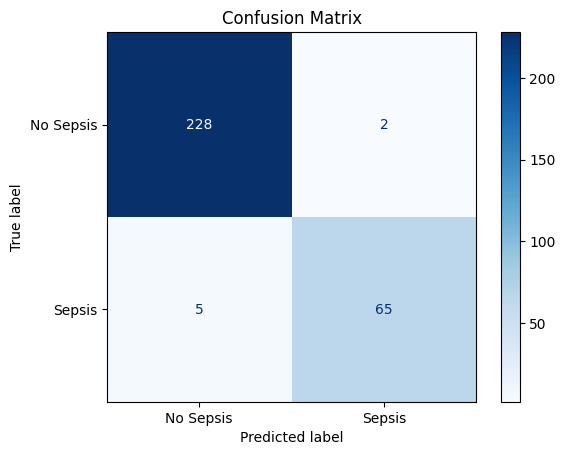

[INFO 06-06 17:39:32] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.
[INFO 06-06 17:39:32] ax.api.client: Generated new trial 0 with parameters {'max_depth': 6, 'learning_rate': 0.155, 'subsample': 0.75, 'colsample_bytree': 0.75} using GenerationNode CenterOfSearchSpace.
[INFO 06-06 17:39:32] ax

AUC-ROC: 0.9994
F1: 0.9630
Sensitivity: 0.9286
Time: 0.0002


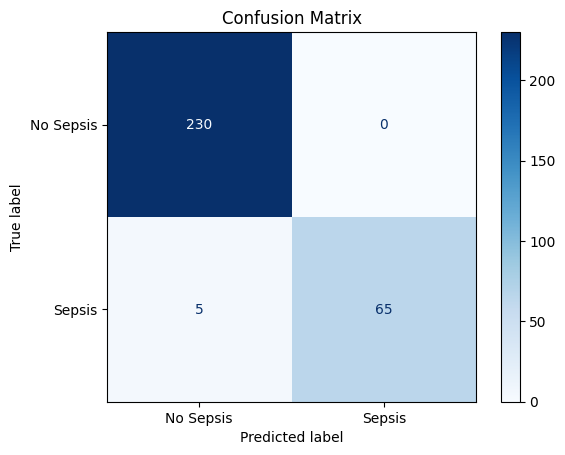

5:{'XGBoost': {'before': {'roc_auc': 0.9972670807453416, 'sensitivity': 0.9285714285714286, 'accuracy': 0.9766666666666667, 'f1_score': 0.948905109489051}, 'after': {'roc_auc': 0.9994409937888198, 'sensitivity': 0.9285714285714286, 'accuracy': 0.9833333333333333, 'f1_score': 0.9629629629629629}}}
AUC-ROC: 0.9973
F1: 0.9489
Sensitivity: 0.9286
Time: 0.0033


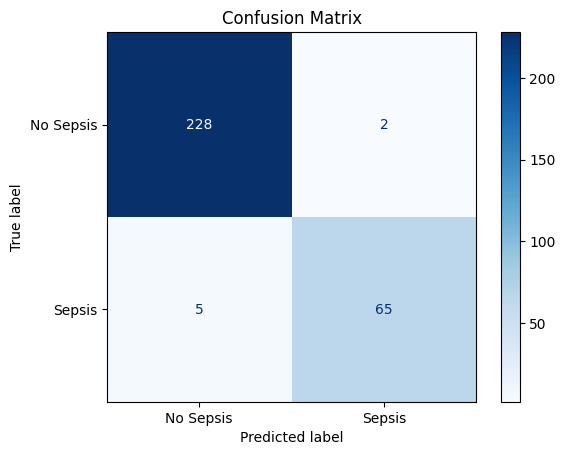

[INFO 06-06 17:39:34] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.
[INFO 06-06 17:39:34] ax.api.client: Generated new trial 0 with parameters {'max_depth': 6, 'learning_rate': 0.155, 'subsample': 0.75, 'colsample_bytree': 0.75} using GenerationNode CenterOfSearchSpace.
[INFO 06-06 17:39:34] ax

AUC-ROC: 0.9999
F1: 0.9855
Sensitivity: 0.9714
Time: 0.0002


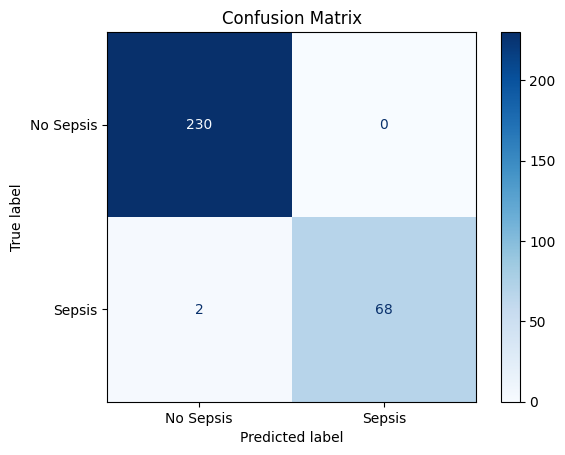

10:{'XGBoost': {'before': {'roc_auc': 0.9972670807453416, 'sensitivity': 0.9285714285714286, 'accuracy': 0.9766666666666667, 'f1_score': 0.948905109489051}, 'after': {'roc_auc': 0.9999378881987578, 'sensitivity': 0.9714285714285714, 'accuracy': 0.9933333333333333, 'f1_score': 0.9855072463768116}}}
AUC-ROC: 0.9973
F1: 0.9489
Sensitivity: 0.9286
Time: 0.0024


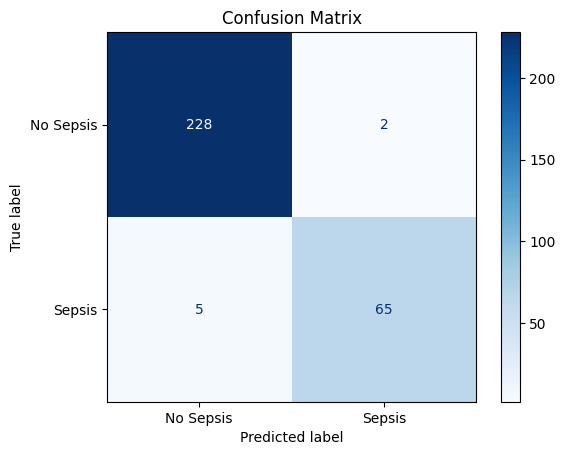

[INFO 06-06 17:39:51] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.
[INFO 06-06 17:39:51] ax.api.client: Generated new trial 0 with parameters {'max_depth': 6, 'learning_rate': 0.155, 'subsample': 0.75, 'colsample_bytree': 0.75} using GenerationNode CenterOfSearchSpace.
[INFO 06-06 17:39:51] ax

AUC-ROC: 0.9999
F1: 0.9855
Sensitivity: 0.9714
Time: 0.0002


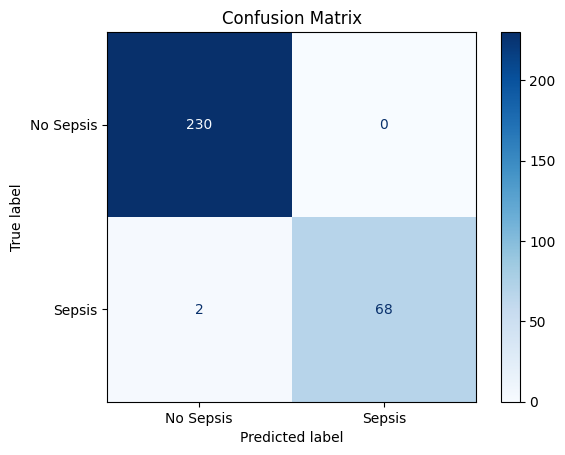

15:{'XGBoost': {'before': {'roc_auc': 0.9972670807453416, 'sensitivity': 0.9285714285714286, 'accuracy': 0.9766666666666667, 'f1_score': 0.948905109489051}, 'after': {'roc_auc': 0.9999378881987578, 'sensitivity': 0.9714285714285714, 'accuracy': 0.9933333333333333, 'f1_score': 0.9855072463768116}}}
AUC-ROC: 0.9973
F1: 0.9489
Sensitivity: 0.9286
Time: 0.0018


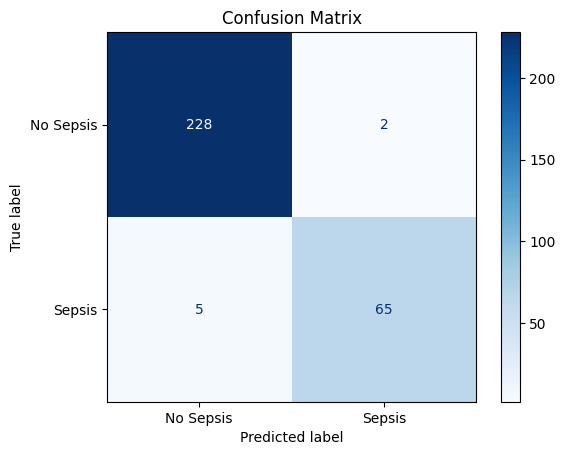

[INFO 06-06 17:40:23] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.
[INFO 06-06 17:40:23] ax.api.client: Generated new trial 0 with parameters {'max_depth': 6, 'learning_rate': 0.155, 'subsample': 0.75, 'colsample_bytree': 0.75} using GenerationNode CenterOfSearchSpace.
[INFO 06-06 17:40:23] ax

AUC-ROC: 0.9999
F1: 0.9855
Sensitivity: 0.9714
Time: 0.0002


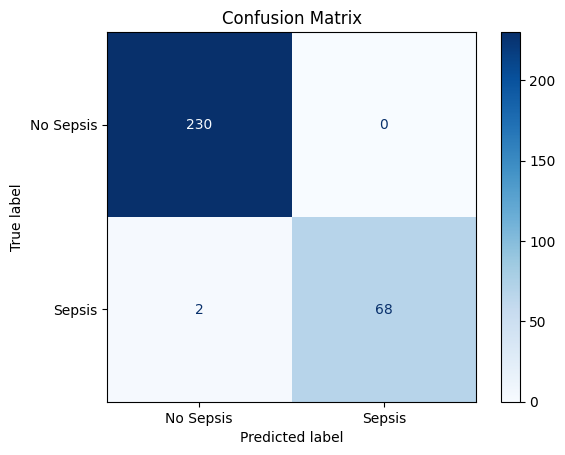

20:{'XGBoost': {'before': {'roc_auc': 0.9972670807453416, 'sensitivity': 0.9285714285714286, 'accuracy': 0.9766666666666667, 'f1_score': 0.948905109489051}, 'after': {'roc_auc': 0.9999378881987578, 'sensitivity': 0.9714285714285714, 'accuracy': 0.9933333333333333, 'f1_score': 0.9855072463768116}}}
AUC-ROC: 0.9973
F1: 0.9489
Sensitivity: 0.9286
Time: 0.0025


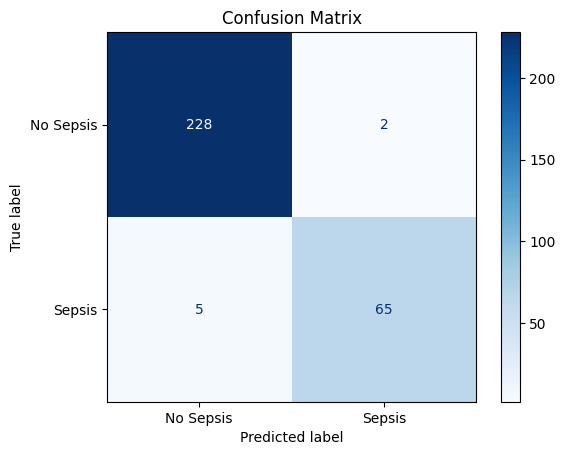

[INFO 06-06 17:41:13] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.
[INFO 06-06 17:41:13] ax.api.client: Generated new trial 0 with parameters {'max_depth': 6, 'learning_rate': 0.155, 'subsample': 0.75, 'colsample_bytree': 0.75} using GenerationNode CenterOfSearchSpace.
[INFO 06-06 17:41:13] ax

AUC-ROC: 1.0000
F1: 0.9781
Sensitivity: 0.9571
Time: 0.0002


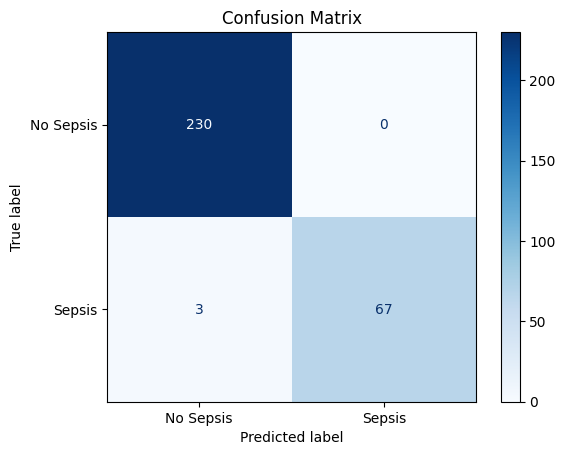

30:{'XGBoost': {'before': {'roc_auc': 0.9972670807453416, 'sensitivity': 0.9285714285714286, 'accuracy': 0.9766666666666667, 'f1_score': 0.948905109489051}, 'after': {'roc_auc': 1.0, 'sensitivity': 0.9571428571428572, 'accuracy': 0.99, 'f1_score': 0.9781021897810219}}}
AUC-ROC: 0.9973
F1: 0.9489
Sensitivity: 0.9286
Time: 0.0028


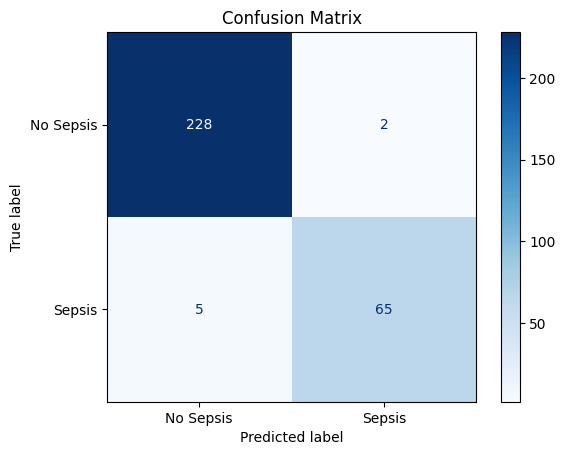

[INFO 06-06 17:42:43] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.
[INFO 06-06 17:42:43] ax.api.client: Generated new trial 0 with parameters {'max_depth': 6, 'learning_rate': 0.155, 'subsample': 0.75, 'colsample_bytree': 0.75} using GenerationNode CenterOfSearchSpace.
[INFO 06-06 17:42:43] ax

AUC-ROC: 1.0000
F1: 0.9928
Sensitivity: 0.9857
Time: 0.0002


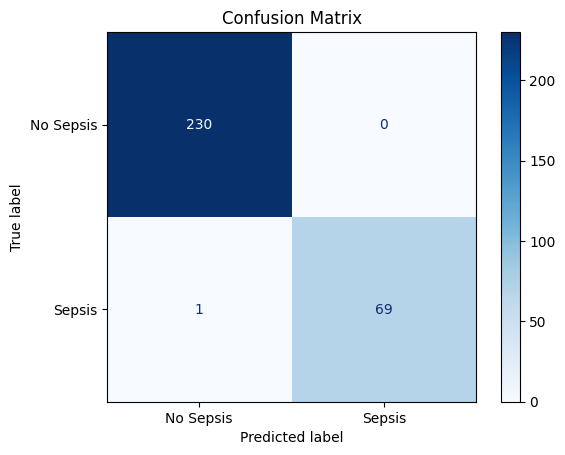

40:{'XGBoost': {'before': {'roc_auc': 0.9972670807453416, 'sensitivity': 0.9285714285714286, 'accuracy': 0.9766666666666667, 'f1_score': 0.948905109489051}, 'after': {'roc_auc': 1.0, 'sensitivity': 0.9857142857142858, 'accuracy': 0.9966666666666667, 'f1_score': 0.9928057553956835}}}


In [80]:
# Usage
path = r"C:\Users\tvlan\Documents\Data Mining\1.0 Assignment\2.0 Assignment 2\2.0 Dataset\early_sepsis_full_simulated_dataset_dropped_encoded_20260603_145114.csv"
input = [5,10,15,20,30,40]

for i in input:
    clf = SepsisClassifier(
        path=path,
        target="sepsis_risk",   # replace with your actual target column name
        label0="No Sepsis",
        label1="Sepsis",
        iter = i
    )

    results = clf.run()
    print(f"{i}:{results}")